In [82]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import re
import string
from pyvi import ViUtils
from sklearn.model_selection import train_test_split
from underthesea import word_tokenize
from joblib import Parallel, delayed
import multiprocessing
import emoji

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid")
print("Import thành công")

Import thành công


In [84]:
path = os.path.join('..', 'data', 'raw', 'Product_review_unlabel.xlsx')
df = pd.read_excel(path)

print('Đọc dữ liệu thành công')

Đọc dữ liệu thành công


In [85]:
def load_dict(path, mode="pair"):
    data = {}

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split('\t')

            # dạng key-value (teencode, emoji)
            if mode == "pair":
                if len(parts) >= 2:
                    key = parts[0]
                    value = parts[1].strip()
                    data[key] = value

            # dạng 1 cột (keyword)
            elif mode == "list":
                data[parts[0]] = True   # dùng như set

    return data

In [86]:
teencode_dict = load_dict('../dicts/teencode.txt', mode="pair")
emoji_dict    = load_dict('../dicts/emoji.txt', mode="pair")
keyword_dict  = load_dict('../dicts/keyword.txt', mode="list")

In [87]:
df = df.dropna(subset=['comment', 'rating'])

In [88]:
keywords = list(keyword_dict.keys())

def contains_keyword(text):
    text = str(text).lower()
    return any(kw in text for kw in keywords)

df = df[df['comment'].apply(contains_keyword)]

In [89]:
def labeling(star):
    if pd.isna(star):
        return None
    elif star <= 2:
        return 0   # Negative
    elif star == 3:
        return 1   # Neutral
    elif star >= 4:
        return 2   # Positive
    else:
        return None

df['label'] = df['rating'].apply(labeling)

In [90]:
df_pos_raw = df[df['label'] == 2]
df_neg_raw = df[df['label'] == 0]
df_neu_raw = df[df['label'] == 1]

data = pd.DataFrame({
    "Nhóm": ["Tích cực", "Tiêu cực", "Trung tính"],
    "Số lượng": [
        df_pos_raw.shape[0],
        df_neg_raw.shape[0],
        df_neu_raw.shape[0]
    ]
})

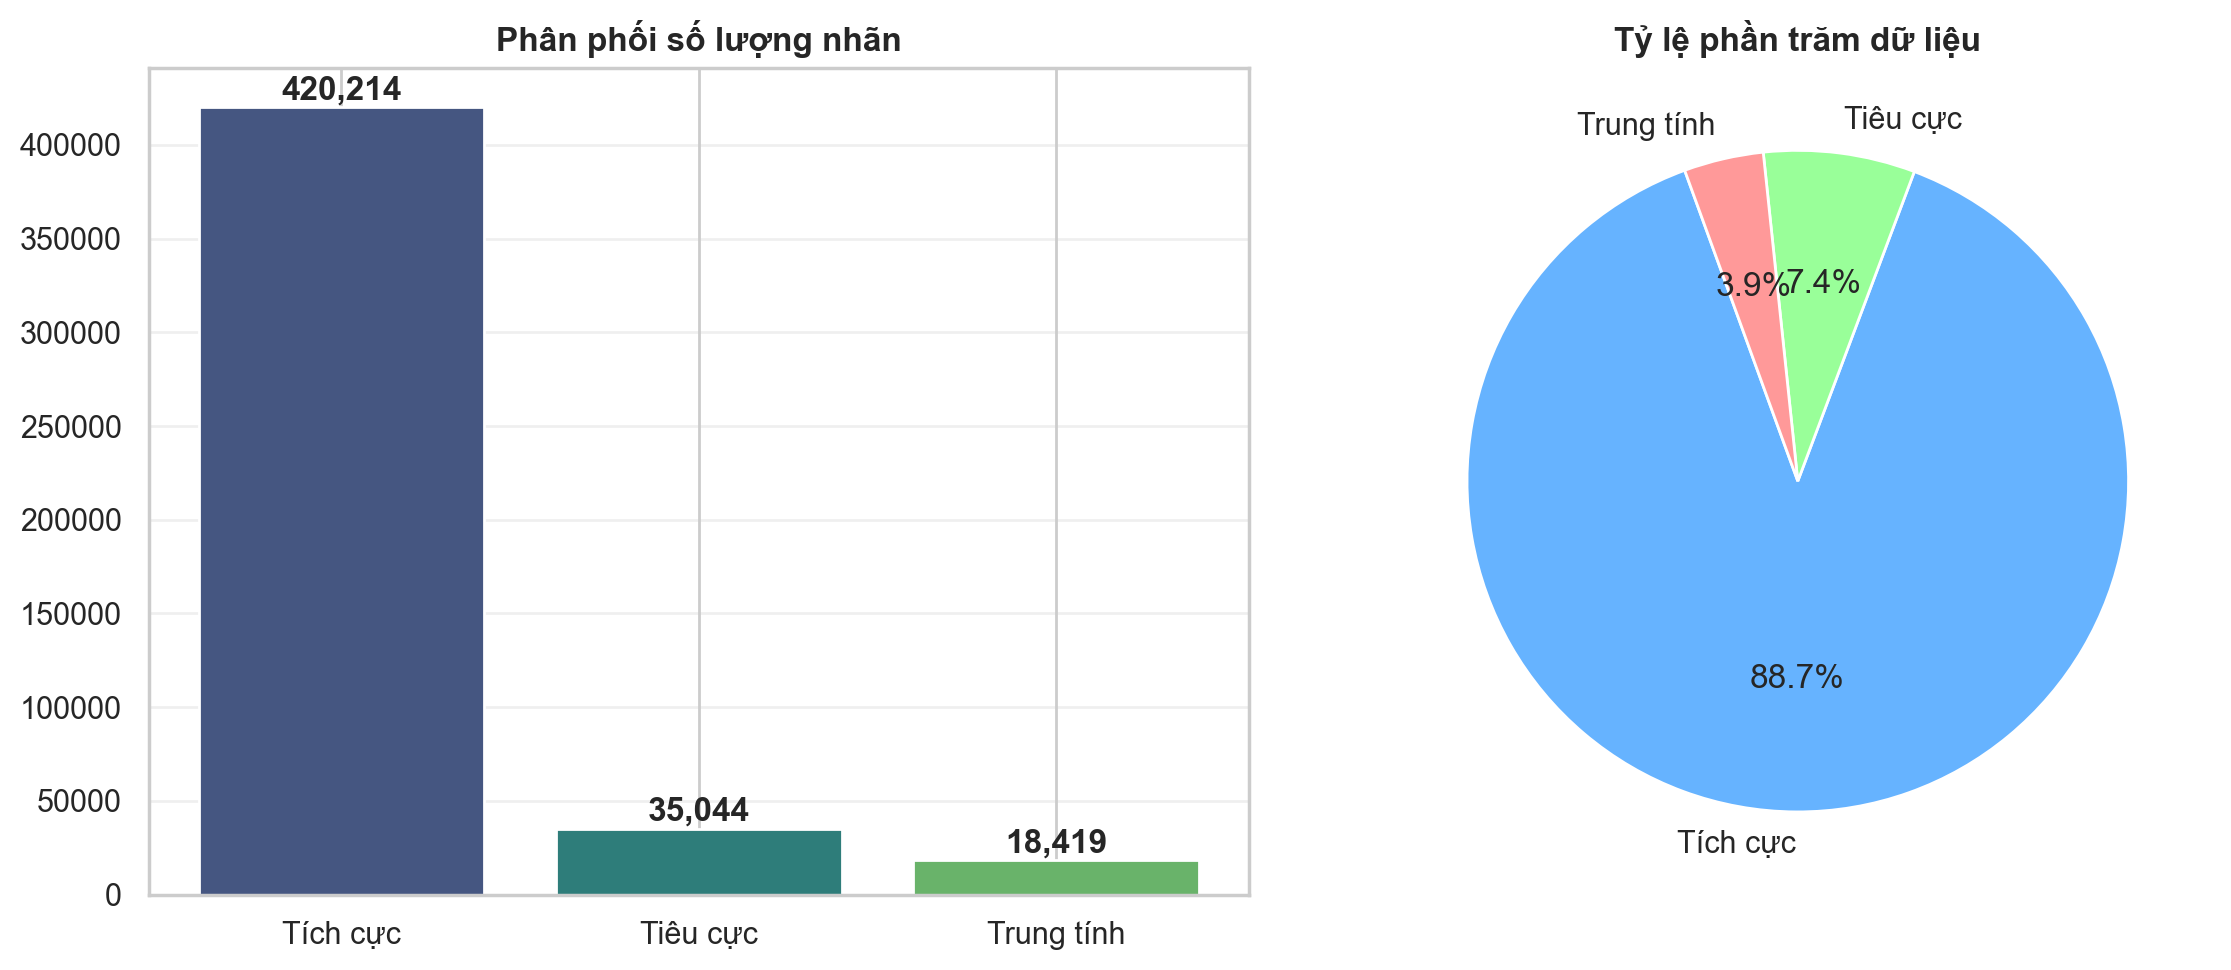

In [91]:
bar_colors = ['#455681', '#2e7d7a', '#69b36a']
pie_colors = ['#66b3ff', '#99ff99', '#ff9999']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- Bar Chart ---
ax[0].bar(data["Nhóm"], data["Số lượng"], color=bar_colors)
ax[0].set_title("Phân phối số lượng nhãn", fontweight='bold')
ax[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(data["Số lượng"]):
    ax[0].text(i, v + max(data["Số lượng"])*0.01, f"{v:,}", ha='center', fontweight='bold')

# --- Pie Chart ---
ax[1].pie(
    data["Số lượng"],
    labels=data["Nhóm"],
    autopct='%1.1f%%',
    startangle=110,
    colors=pie_colors
)
ax[1].set_title("Tỷ lệ phần trăm dữ liệu", fontweight='bold')

plt.tight_layout()
plt.show()

In [92]:
SAMPLE_SIZE = 30000
ratio = {2: 0.40, 0: 0.35, 1: 0.25}

n_pos = int(SAMPLE_SIZE * ratio[2])
n_neg = int(SAMPLE_SIZE * ratio[0])
n_neu = int(SAMPLE_SIZE * ratio[1])

def safe_sample(data, n):
    return data.sample(n=min(n, len(data)), random_state=42)

df_pos = safe_sample(df[df['label'] == 2], n_pos)
df_neg = safe_sample(df[df['label'] == 0], n_neg)
df_neu = safe_sample(df[df['label'] == 1], n_neu)

df_final = pd.concat([df_pos, df_neg, df_neu]).sample(frac=1, random_state=42)

print("Final size:", len(df_final))
print(df_final['label'].value_counts())

Final size: 30000
label
2    12000
0    10500
1     7500
Name: count, dtype: int64


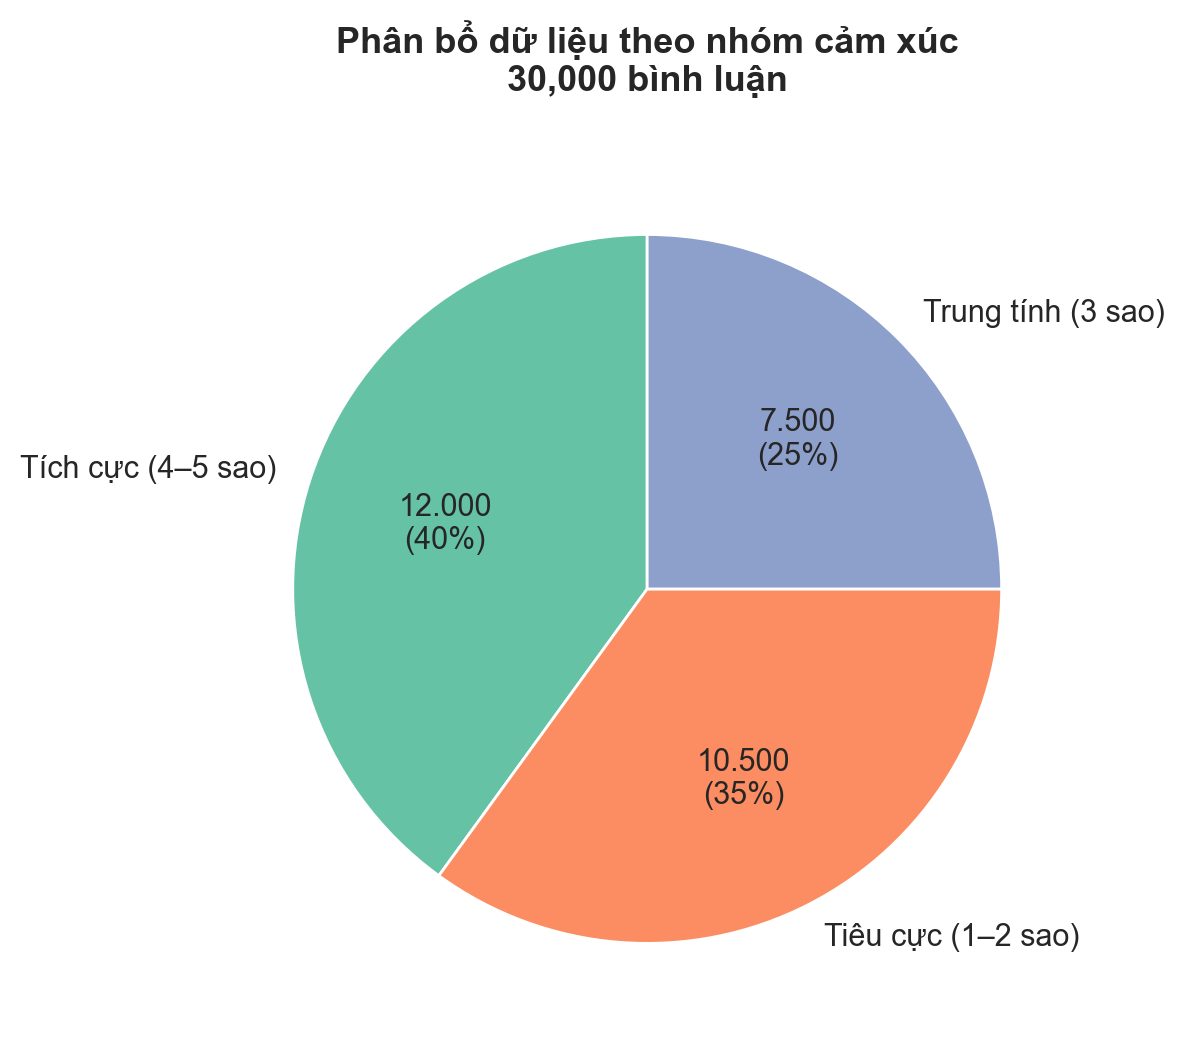

In [93]:
fig, ax = plt.subplots(figsize=(6, 6))

pie_labels = ['Tích cực (4–5 sao)', 'Tiêu cực (1–2 sao)', 'Trung tính (3 sao)']
pie_sizes = [
    len(df_pos),
    len(df_neg),
    len(df_neu)
]

pie_colors = ['#66c2a5', '#fc8d62', '#8da0cb']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val:,}\n({pct:.0f}%)'.replace(',', '.')
    return my_autopct

ax.pie(
    pie_sizes,
    labels=pie_labels,
    autopct=make_autopct(pie_sizes),
    startangle=90,
    colors=pie_colors,
    textprops={'fontsize': 11}
)

ax.set_title(
    f"Phân bổ dữ liệu theo nhóm cảm xúc\n{len(df_final):,} bình luận",
    fontweight='bold', fontsize=13, pad=20
)

plt.tight_layout()
plt.show()

In [94]:
assert len(df_pos_raw) >= n_pos, "Không đủ mẫu rating 4-5"
assert len(df_neg_raw) >= n_neg, "Không đủ mẫu rating 1-2"
assert len(df_neu_raw) >= n_neu, "Không đủ mẫu rating 3"

df_pos_sample = resample(df_pos_raw, n_samples=n_pos, replace=False, random_state=42)
df_neg_sample = resample(df_neg_raw, n_samples=n_neg, replace=False, random_state=42)
df_neu_sample = resample(df_neu_raw, n_samples=n_neu, replace=False, random_state=42)

df = (
    pd.concat([df_pos_sample, df_neg_sample, df_neu_sample])
      .sample(frac=1, random_state=42)
      .reset_index(drop=True)
)

print("Dataset sau sampling:", len(df))

Dataset sau sampling: 30000


In [95]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['label']
)

dev_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

print("Train:", train_df.shape)
print("Dev:", dev_df.shape)
print("Test:", test_df.shape)

Train: (21000, 8)
Dev: (4500, 8)
Test: (4500, 8)


In [96]:
def remove_spam(review):
    """Remove spam and tags like [TB], [QC]"""
    review = str(review)

    # Xóa tag [TB], [QC]
    review = re.sub(r"\[(TB|QC)\]", "", review, flags=re.IGNORECASE)

    # Nếu chứa nội dung spam → bỏ luôn
    spam_patterns = [
        r"http\S*",
        r"www\S*",
        r"\.com",
        r"mua ngay",
        r"liên hệ",
        r"zalo",
        r"fb",
        r"facebook",
        r"\d{9,11}"
    ]

    for pattern in spam_patterns:
        if re.search(pattern, review.lower()):
            return ""

    return review.strip()

In [97]:
def to_lowercase(text):
    text = str(text).lower()
    return text

In [98]:
def remove_labeled_tags(text):
    text = re.sub(r'[^:\n]+:\s*', '', text)
    return text

In [99]:
def remove_all_tag(sentence):
    """Remove tags added from reading files"""
    return re.sub(r'\n|\t|\r', ' ', sentence)

In [100]:
def replace_emoji(text, emoji_dict):
    if not isinstance(text, str):
        return ""

    # 1. Replace emoji có trong dict
    for emo, label in emoji_dict.items():
        text = text.replace(emo, f" {label} ")

    # 2. Xóa toàn bộ emoji còn lại (không có trong dict)
    text = emoji.replace_emoji(text, replace='')

    return text

In [101]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

In [102]:
def convert_teencode(text, teencode_dict):
    words = text.split()
    new_words = []

    for word in words:
        if word in teencode_dict:
            new_words.append(teencode_dict[word])
        else:
            new_words.append(word)

    return " ".join(new_words)

In [103]:
def remove_duplicate_letters(text):
    return " ".join(
        re.sub(r'(.)\1+', r'\1', w)
        for w in text.split()
    )

In [104]:
def remove_punctuation(text):
    return re.sub(r'[^\w\sÀ-ỹ]', ' ', text)

In [105]:
def remove_nonsense_words(text):
    vowels = "aeiouyàáạảãăắằẳẵặâấầẩẫậèéẹẻẽêếềểễệìíịỉĩòóọỏõôốồổỗộơớờởỡợùúụủũưứừửữự"

    words = text.split()
    clean_words = []

    for w in words:

        # bỏ từ quá dài
        if len(w) > 20:
            continue

        # kiểm tra tỷ lệ nguyên âm
        vowel_count = sum(1 for c in w if c in vowels)
        if len(w) > 6 and vowel_count / len(w) < 0.2:
            continue

        clean_words.append(w)

    return " ".join(clean_words)

In [106]:
def clean_text(text):
    text = remove_spam(text)
    text = to_lowercase(text)
    text = remove_labeled_tags(text)
    
    text = remove_all_tag(text)
    text = replace_emoji(text, emoji_dict)
    text = remove_numbers(text)

    text = remove_duplicate_letters(text)

    # thay dấu câu bằng khoảng trắng
    text = remove_punctuation(text)

    text = convert_teencode(text, teencode_dict)

    # chuẩn hóa khoảng trắng trước khi tokenize
    text = re.sub(r'\s+', ' ', text).strip()

    # bỏ từ rác
    text = remove_nonsense_words(text)

    return text

In [107]:
def clean_dataframe(df, name):
    clean_results = Parallel(
        n_jobs=6, 
        backend="loky", 
        batch_size=200, 
        verbose=0
    )(
        delayed(clean_text)(text) for text in df['comment']
    )
    
    df['clean_review'] = clean_results
    
    # Remove NaN & empty
    before = len(df)
    df = df.dropna(subset=['clean_review'])
    df = df[df['clean_review'].str.strip() != ""].copy()
    after = len(df)
    
    return df

In [108]:
train_df = clean_dataframe(train_df, "Train")
dev_df   = clean_dataframe(dev_df, "Dev")
test_df  = clean_dataframe(test_df, "Test")

In [109]:
display(train_df[['comment', 'clean_review', 'label']].head(5))
display(dev_df[['comment', 'clean_review', 'label']].head(5))
display(test_df[['comment', 'clean_review', 'label']].head(5))

,comment,clean_review,label
7428,Chất liệu:hơi kém\nMàu sắc:màu đúg,hơi kém màu đúng,0
8677,"Giao hàng nhanh, nhưng đồ hơi nhỏ shop rep tin...",giao hàng nhanh nhưng đồ hơi nhỏ cửa hàng trả ...,1
24739,Màu sắc:kem\nĐúng với mô tả:mỏng nhiều chỉ thừ...,kém mỏng nhiều chỉ thừa nhưng mát phù hợp mùa ...,1
9012,vải hơi thô và cứng chứ ko mềm \ntiền nào của ...,vải hơi thô và cứng chứ không mềm tiền nào của...,1
26091,Đúng với mô tả:ko\nChất liệu:vải mỏng\nMàu sắc...,không vải mỏng trắng không giống ảnh cho lắm c...,1


,comment,clean_review,label
9068,Màu sắc:trắng\nChất liệu:khác\nĐúng với mô tả:...,trắng khác không áo mỏng hình in thì mờ nếu lầ...,1
21829,Chất lượng sản phẩm:ok,ok,2
23572,Chất lượng sản phẩm:rất là mau hết pin\nĐúng v...,rất là mau hết pin không đúng mo ta,0
15498,So với giá tiền thì cái này quá tệ,so với giá tiền thì cái này quá tệ,0
19394,Nhận hàng cường lực bị vỡ.\nSản phẩm không đảm...,nhận hàng cường lực bị vỡ sản phẩm không đảm bảo,0


,comment,clean_review,label
2662,Vãi hơi cứng nhưng chất lượng cũng được,vãi hơi cứng nhưng chất lượng cũng được,1
7487,Màu sắc:trắng\nĐúng với mô tả:ko đúng vs mô tả...,trắng không đúng với mô tả vải,1
8859,Chất liệu:Vãi\nMàu sắc:đen\nĐúng với mô tả:đún...,vãi đen đúng nên mua ủng hộ cửa hàng hàng đẹp,2
19237,Shop làm ăn như qq vậy.chỗ bấm điều khiển thì ...,cửa hàng làm ăn như q vậy chỗ bấm điều khiển t...,0
10882,Đúng với mô tả:cứng\nChất liệu:mỏng\nMàu sắc:đ...,cứng mỏng đúng nói chung tạm ổn,2


In [110]:
output_dir = os.path.join('..', 'data', 'processed')
os.makedirs(output_dir, exist_ok=True)

train_df.to_excel(os.path.join(output_dir, 'train.xlsx'), index=False)
dev_df.to_excel(os.path.join(output_dir, 'dev.xlsx'), index=False)
test_df.to_excel(os.path.join(output_dir, 'test.xlsx'), index=False)

print("Đã lưu 3 tập dữ liệu")

Đã lưu 3 tập dữ liệu


In [111]:
n_train = len(train_df)
n_dev   = len(dev_df)
n_test  = len(test_df)

# Tổng
total = n_train + n_dev + n_test

# In kết quả
print(f"Train: {n_train}")
print(f"Dev: {n_dev}")
print(f"Test: {n_test}")
print("-" * 30)
print(f"Tổng dữ liệu: {total}")

Train: 20591
Dev: 4417
Test: 4431
------------------------------
Tổng dữ liệu: 29439
